In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from resources.lattices import connectivity

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch_geometric.nn import GCNConv, global_mean_pool, global_add_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx

import optuna
import networkx as nx

In [3]:
# from resources.MachineLearning import ...
%run MLdata.ipynb 
%run MLfunc.ipynb

# Graph Neural Network (GNN)

## Graph Convolutional Network (GCN)

In [4]:
class GCNhlayer(nn.Module):
    def __init__(self, in_size, out_size, norm=None):
        super(GCNhlayer, self).__init__()
        self.norm = norm
        self.fc = nn.Linear(in_size, out_size)
        self.act = nn.ReLU()
        if norm:
            self.norm = nn.LayerNorm(out_size)
    
    def forward(self, x):
        x = self.act(self.fc(x))
        if self.norm:
            x = self.norm(x)
        return x

class GCN(nn.Module):
    def __init__(self, in_size, h_size, out_size, norm=None):
        super(GCN, self).__init__()
        self.norm = norm
        self.GconvIN = GCNConv(in_size, h_size[0])
        self.Gconv1 = GCNConv(h_size[0], h_size[1])
        self.Gconv2 = GCNConv(h_size[1], h_size[2])
        self.Gconv3 = GCNConv(h_size[2], h_size[-1])
        self.GconvOUT = GCNConv(h_size[-1], out_size)
        self.fcOUT = nn.Linear(h_size[-1], out_size)
        self.act = nn.ReLU()
        if norm:
            self.normIN = nn.LayerNorm(h_size[0])
        self.dropout = nn.Dropout(0.25)
        #self.hlayers = nn.Sequential(*[MLPhlayer(i, j, norm) for i, j in zip(h_size[:-1], h_size[1:])])

    def forward(self, x, edge_index, batch):
        x = self.act(self.GconvIN(x, edge_index))
        x = self.act(self.Gconv1(x, edge_index))
        x = self.act(self.Gconv2(x, edge_index))
        x = self.act(self.Gconv3(x, edge_index))
        #x = self.act(self.GconvOUT(x, edge_index))
        x = global_mean_pool(x, batch)
        x = self.fcOUT(x)
        # if self.norm: 
        #     x = self.normIN(x)
        # x = self.hlayers(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")#, torch.cuda.is_available(), torch.cuda.get_device_name(0)

Using device: cpu


## Graph Attention Network (GAT)

# Stress-Strain Curve Optimization
General approximation from change in node coordinate components to change in stress-strain curve.

In [5]:
train_in_ = train_in.reshape(len(train_in),int(len(train_in[0])/2),2)
train_out_ = train_outST

val_in_ = val_in.reshape(len(val_in),int(len(val_in[0])/2),2)
val_out_ = val_outST

test_in_ = test_in.reshape(len(test_in),int(len(test_in[0])/2),2)
test_out_ = test_outST

In [6]:
train_in_.shape, train_out_.shape

((3583, 357, 2), (3583, 201))

In [7]:
perIN_ = perIN.reshape(int(len(perIN)/2), 2)
perIN_ = np.array([i for i in perIN_ if max(perIN_[:,0]) != i[0] and min(perIN_[:,0]) != i[0] and 
                                        max(perIN_[:,1]) != i[1] and min(perIN_[:,1]) != i[1]])
elems = connectivity("FCC", perIN_/1000, [10/1000]*20)

edges = elems[:, 1:] - 1
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [8]:
in_size = train_in_.shape[-1]
out_size = train_out_.shape[-1]
h_size = [2**3, 2**4, 2**5, 2**7]

BATCH_SIZE = 16
LEARNING_RATE = 1e-3
n_epochs = 2000

In [9]:
trainDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(train_in_[:500], train_out_[:500])]
valDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(val_in_, val_out_)]
testDS = [Data(x=torch.tensor(i, dtype=torch.float), edge_index=edge_index, y=torch.tensor(j, dtype=torch.float)) for i,j in zip(test_in_, test_out_)]

train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=valDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=testDS, batch_size=BATCH_SIZE, shuffle=False)

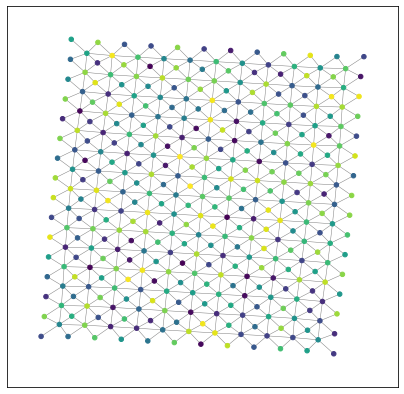

In [10]:
visualize_graph(train_dataloader, colors=None, layout="kk")

In [16]:
gcn1 = GCN(in_size, h_size, out_size).to(device)
gcn1.apply(weights_init)
# print(torch.cuda.is_available())   ### TODO: GPU

opt = optim.Adam(gcn1.parameters(), lr=LEARNING_RATE)
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=50, min_delta=1e-4, verbose=True)

ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.2427, patience=15, threshold=1e-4, verbose=True)
OneCycleLR = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, steps_per_epoch=len(train_dataloader), epochs=n_epochs)
CosineAnnealingLR = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

In [17]:
gcn1, epoch, train_lossLog, val_lossLog = train_model('gcn', gcn1, lossf, n_epochs, opt, train_dataloader, 
                                                      val_dataloader=val_dataloader, scheduler=ReduceLR, earlyStop=earlyStop,
                                                      verbose=10)

Epoch: 1 - Loss: 0.3030126690864563
Epoch: 10 - Loss: 0.18900124728679657


KeyboardInterrupt: 

In [13]:
plot_loss(epoch, train_lossLog, val_lossLog)

NameError: name 'epoch' is not defined

In [14]:
test_outputs = predict_model("gcn", gcn1, test_dataloader)
test_outputs = standardize(test_outputs, outParams[0], outParams[1], mode=1)

NameError: name 'gcn1' is not defined

NameError: name 'test_outputs' is not defined

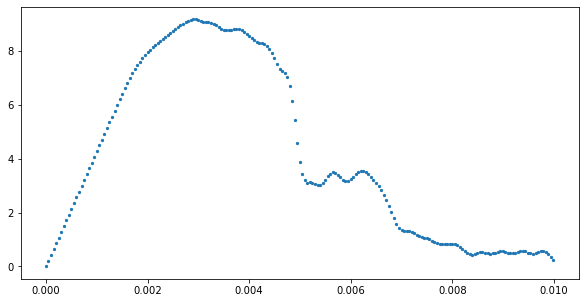

In [15]:
fig = plt.figure(figsize=(10, 5))
plt.scatter(perOUT[0], train_out[10]+perOUT[1], s=5, label="Truth")
plt.scatter(perOUT[0], test_outputs[10]+perOUT[1], s=5, label="Prediction")
plt.ylabel("Stress ($\sigma$) [MPa]")
plt.xlabel("Strain ($\epsilon$)")
plt.legend()
plt.grid()

In [18]:
err = list(abs(sum(test_out[:,60:140] - test_outputs[:,60:140])))
err.index(min(err)), err.index(max(err))

NameError: name 'test_outputs' is not defined